---

# Probabilistic Forecasting

By: Tomás Urdiales

-> Notebook containing early experiments with quantile regression, as well as notes on handling probabilistic forecasts.

##### Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression, QuantileRegressor

from src import utils
from src.cross_validation import backtesting_CV
from src.join_qh_min_data import join_qh_min_data

##### Parameters

In [2]:
CWD = utils.get_root_dir()

# To not use darts plotting style:
plt.style.use('default')

DPI = 150 # (pixel density for figures)
ELIA_ORANGE = (250/256, 115/256, 1/256) # RGB

##### Load data

In [3]:
qh = utils.load_qh_historical_data().loc["2021":"2022"]
minute = utils.load_min_historical_data().loc["2021":"2022"]
ems = utils.load_ems_historical_data().loc["2021":"2022"]

In [4]:
# Legacy set
MINUTE = 8

qh_parameters = {
    "system_imbalance_cum15": {
        "lags": [1]},
    "si_mw": {
        "lags": [-1, -2, -3, -4]},
    "load_id_mw": {
        "lags": [3, 2, 1, 0, -1, -2, -3, -4]},
    "nrv_rt": {
        "lags": [-1, -2, -3, -4]},
}

minute_parameters = {
    "system_imbalance": {
        "lags": [0, -1, -2, -3]},
    "net_regulation_volume": {
        "lags": [0, -1, -2, -3]},
}

# Prepare training dataframe:
df = join_qh_min_data(
    qh_data=qh,
    minute_data=minute,
    qh_parameters=qh_parameters,
    minute_parameters=minute_parameters,
    minute=MINUTE,
)
TARGET = "system_imbalance_cum15_from_qh_plus_1"
FEATURES = [feature for feature in df.columns if feature != TARGET]

df = df.dropna()

---

## Quantile regressor

In [5]:
# Set up splits and model features:
tscv = TimeSeriesSplit(n_splits=52 * 7 // 4, max_train_size=4 * 24 * 7 * 4, test_size=4 * 24 * 4, gap=0)

# Cross-validation:
results_linear = backtesting_CV(model=LinearRegression(),
                                data=df,
                                time_splits=tscv,
                                use_scaler=False,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                verbose=False)

results_quantile_p50 = backtesting_CV(model=QuantileRegressor(quantile=0.5, solver="highs"),
                                      data=df,
                                      time_splits=tscv,
                                      use_scaler=False,
                                      features=FEATURES,
                                      target=TARGET,
                                      progress_bar=True,
                                      verbose=False,
                                      print_error_metrics=False)

results_quantile_p10 = backtesting_CV(model=QuantileRegressor(quantile=0.10, solver="highs"),
                                      data=df,
                                      time_splits=tscv,
                                      use_scaler=False,
                                      features=FEATURES,
                                      target=TARGET,
                                      progress_bar=True,
                                      verbose=False,
                                      print_error_metrics=False)

results_quantile_p90 = backtesting_CV(model=QuantileRegressor(quantile=0.9, solver="highs"),
                                      data=df,
                                      time_splits=tscv,
                                      use_scaler=False,
                                      features=FEATURES,
                                      target=TARGET,
                                      progress_bar=True,
                                      verbose=False,
                                      print_error_metrics=False)

quant_reg = pd.DataFrame(dict(mean=results_linear[0]["y_pred"], \
    p10=results_quantile_p10[0]["y_pred"], \
    p90=results_quantile_p90[0]["y_pred"]))

MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 4 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:13<00:00,  6.54it/s]



MASE: 0.7136 | MAE: 106.97MW | RMSE: 142.13MW | P90 Error: 225.92MW | Max Error: 1024.2 (2022-09-06 21:23:00+02:00)
Time elapsed: 13.94s | Time per split: ~0.15s

MODEL: QuantileRegressor
Time configuration: 91 splits, 4 testing days, 4 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:40<00:00,  2.23it/s]


MODEL: QuantileRegressor
Time configuration: 91 splits, 4 testing days, 4 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:35<00:00,  2.59it/s]


MODEL: QuantileRegressor
Time configuration: 91 splits, 4 testing days, 4 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:36<00:00,  2.48it/s]


79.04% of the prediction intervals contain true target.


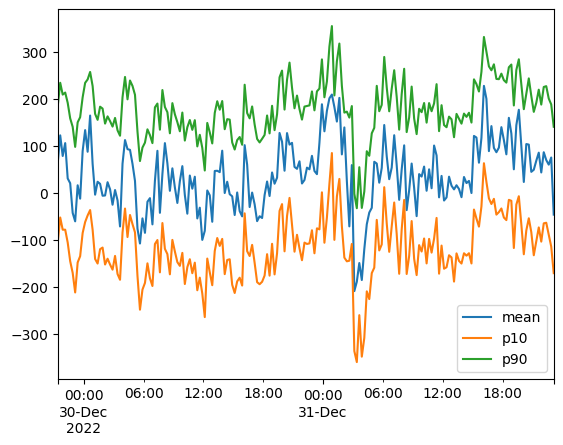

In [6]:
quant_reg.tail(200).plot()

quant_reg_correct = np.mean(
    results_linear[0]["y_test"].between(quant_reg['p10'], quant_reg['p90'])
)
print(f"{quant_reg_correct:.2%} of the prediction intervals contain true target.")

---

## Using statsmodels

In [7]:
from scipy.stats import t
import statsmodels.api as sm

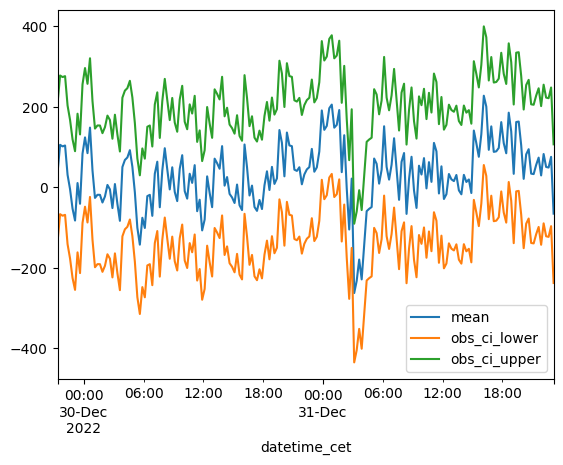

In [8]:
# Ordinary Least Squares through statsmodels:
ols = sm.OLS(df[TARGET], sm.add_constant(df[FEATURES])).fit()

ols = (ols
    .get_prediction(sm.add_constant(df[FEATURES]))
    .summary_frame(alpha=0.2)[['mean', 'obs_ci_lower', 'obs_ci_upper']])

ols.tail(200).plot()
plt.show()

In [9]:
ols_correct = np.mean(
    df[TARGET].between(ols['obs_ci_lower'], ols['obs_ci_upper'])
)
print(f"{ols_correct:.2%} of the prediction intervals contain true target.")

83.38% of the prediction intervals contain true target.


---

## Comparison


In [10]:
quant_reg

,mean,p10,p90
2022-01-01 17:38:00+01:00,-58.473602,-195.168701,99.157410
2022-01-01 17:53:00+01:00,11.608948,-139.271667,144.557114
2022-01-01 18:08:00+01:00,-57.813530,-190.715759,92.159370
2022-01-01 18:23:00+01:00,-54.013069,-200.741272,87.930565
2022-01-01 18:38:00+01:00,-56.284264,-182.098251,108.667770
...,...,...,...
2022-12-31 22:08:00+01:00,86.379990,-64.885345,225.148621
2022-12-31 22:23:00+01:00,69.789337,-63.568405,226.880447
2022-12-31 22:38:00+01:00,60.002712,-89.081314,200.565399
2022-12-31 22:53:00+01:00,75.188248,-114.373398,188.068634


In [11]:
ols

,mean,obs_ci_lower,obs_ci_upper
datetime_cet,,,
2021-01-01 01:08:00+01:00,-10.671099,-182.851637,161.509438
2021-01-01 01:23:00+01:00,51.943949,-120.239022,224.126919
2021-01-01 01:38:00+01:00,133.763160,-38.422082,305.948402
2021-01-01 01:53:00+01:00,83.941587,-88.242322,256.125496
2021-01-01 02:08:00+01:00,58.958352,-113.226162,231.142865
...,...,...,...
2022-12-31 22:08:00+01:00,82.566275,-89.623957,254.756507
2022-12-31 22:23:00+01:00,50.465749,-121.725110,222.656608
2022-12-31 22:38:00+01:00,48.975332,-123.221221,221.171885
